[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leaguilar/fit_2026/blob/main/notebooks/2_reinforcement_learning_q_learning.ipynb)

# 2. Aprendizaje por refuerzo: de la Q-table al deep Q-learning

**Taller Hands-On AI | FIT 2026**

Hasta ahora le dimos a la máquina las respuestas correctas y ella ajustó
sus perillas. Ahora nadie le dice la respuesta. Solo hay un **premio**
cuando hace algo bien, y tiene que descubrir sola qué hacer.

| Parte | Qué hacemos |
|---|---|
| 1 | Un mundo de 5 casillas. |
| 2 | La ecuación de Bellman. Llenamos la tabla **a mano** (hoja de trabajo). |
| 3 | Q-learning: la máquina llena la misma tabla sola (**TODO 2**). |
| 4 | Por qué la tabla no escala. |
| 5 | Mundo continuo: la tabla se rompe, la red la reemplaza. |

In [1]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation
from IPython.display import HTML

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

# Los tonos estan elegidos para que se distingan tambien con daltonismo
# rojo-verde (comprobado por script, no a ojo).
AZUL   = "#215CAF"   # el modelo / la red
ROJO   = "#B7352D"   # el error
VERDE  = "#8E9C1E"   # la recompensa / lo correcto
PETROL = "#00A0C6"   # la comparacion
GRIS   = "#6F6F6F"   # ejes y contexto

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass
from ipywidgets import interact, FloatSlider, Dropdown, IntSlider

print("Listo.")

Listo.


---
## 1. El mundo: cinco casillas y una comida

El agente vive en una fila de 5 casillas. En la casilla 3 hay comida.

Puede hacer **tres cosas**: `izquierda`, `derecha`, `comer`.

* Moverse no da nada. Contra la pared se queda donde está.
* `comer` en la casilla 3 da **+10**. `comer` en cualquier otra casilla da 0.
* La comida no se acaba: puede comer una y otra vez.

Eso es todo el mundo. Cinco estados, tres acciones: una tabla de 15 números.

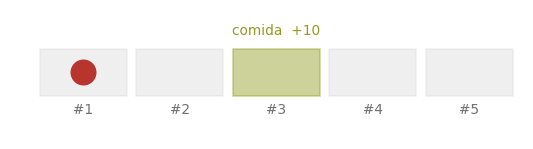

El agente empieza en la casilla 1. Nadie le dijo donde esta la comida.


In [2]:
ACCIONES = ["izquierda", "derecha", "comer"]
N_ESTADOS, N_ACCIONES = 5, 3
CASILLA_COMIDA = 2                     # indice 2 = casilla numero 3

def transicion(s, a):
    """Devuelve (estado nuevo, recompensa)."""
    if a == 0:                              # izquierda
        return max(0, s - 1), 0.0
    if a == 1:                              # derecha
        return min(N_ESTADOS - 1, s + 1), 0.0
    return s, (10.0 if s == CASILLA_COMIDA else 0.0)   # comer

def dibujar_mundo(s=0, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 1.5))
    for i in range(N_ESTADOS):
        color = VERDE if i == CASILLA_COMIDA else "#dddddd"
        ax.add_patch(plt.Rectangle((i, 0), .9, .55, color=color, alpha=.45))
        ax.text(i + .45, -.22, f"#{i+1}", ha="center", color=GRIS)
    ax.text(CASILLA_COMIDA + .45, .72, "comida  +10", ha="center", color=VERDE, fontsize=9)
    ax.plot(s + .45, .28, "o", color=ROJO, ms=16)
    ax.set_xlim(-.3, N_ESTADOS); ax.set_ylim(-.5, 1.0); ax.axis("off")
    return ax

dibujar_mundo(0); plt.show()
print("El agente empieza en la casilla 1. Nadie le dijo donde esta la comida.")

---
## 2. La ecuación de Bellman

Queremos un número $Q(s,a)$ para cada casilla y cada acción: **cuánto vale
hacer la acción $a$ estando en la casilla $s$**. Eso es la Q-table: 5 filas
por 3 columnas.

El valor de una acción es el premio que da **ahora**, más lo que se puede
conseguir **después**, rebajado por un factor $\gamma$:

$$ Q(s,a) \;=\; \underbrace{r}_{\text{premio ahora}}
   \;+\; \gamma \cdot \underbrace{\max_{a'} Q(s',a')}_{\text{lo mejor que se puede hacer despues}} $$

$\gamma$ (*discount*) dice **cuánto pesa el futuro frente al presente**.
Ojo con esto, porque es fácil entenderlo mal: $\gamma$ **no recorta** la cadena.
Si desarrollas la ecuación queda una suma sobre **todos** los pasos futuros,

$$ Q = r_0 + \gamma\, r_1 + \gamma^2 r_2 + \gamma^3 r_3 + \dots $$

y ningún paso se descarta nunca. Lo único que hace $\gamma$ es multiplicar cada
paso por un peso que se encoge: con $\gamma = 0.1$, lo que pase dentro de dos
pasos vale $0.1^2 = 0.01$ veces lo de ahora. Poco, pero **no cero**.

### A mano (10 minutos, hoja de trabajo)

Llena la tabla vacía de tu hoja. Empieza por la casilla más fácil:

* $Q(\#3, \text{comer}) = 10 + 0.1 \times Q(\#3, \text{comer})$, porque
  después de comer sigues en la #3 y lo mejor que puedes hacer es volver a
  comer. Despeja: sale $11.11$.
* $Q(\#2, \text{derecha}) = 0 + 0.1 \times 11.11 = 1.11$.
* $Q(\#1, \text{derecha}) = 0 + 0.1 \times 1.11 = 0.11$.

Sigue tú con el resto.

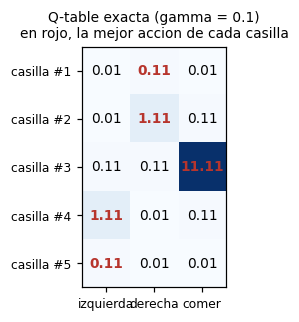

[[1.11000e-02 1.11100e-01 1.11000e-02]
 [1.11000e-02 1.11110e+00 1.11100e-01]
 [1.11100e-01 1.11100e-01 1.11111e+01]
 [1.11110e+00 1.11000e-02 1.11100e-01]
 [1.11100e-01 1.11000e-02 1.11000e-02]]


In [3]:
# La respuesta exacta, calculada por iteracion de valor. Sabemos el mundo
# entero, asi que no hace falta aprender nada: se resuelve.
def tabla_exacta(gamma=0.1, iteraciones=200):
    Q = np.zeros((N_ESTADOS, N_ACCIONES))
    for _ in range(iteraciones):
        Q_nueva = np.zeros_like(Q)
        for s in range(N_ESTADOS):
            for a in range(N_ACCIONES):
                s2, r = transicion(s, a)
                Q_nueva[s, a] = r + gamma * Q[s2].max()
        Q = Q_nueva
    return Q

Q_exacta = tabla_exacta(gamma=0.1)

def mostrar_tabla(Q, titulo="", ax=None, vmax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 3))
    im = ax.imshow(Q, cmap="Blues", vmin=0, vmax=vmax or max(Q.max(), 1e-9))
    for s in range(N_ESTADOS):
        for a in range(N_ACCIONES):
            mejor = a == Q[s].argmax() and Q[s].max() > 0
            ax.text(a, s, f"{Q[s,a]:.2f}", ha="center", va="center",
                    fontsize=9, color=ROJO if mejor else "black",
                    fontweight="bold" if mejor else "normal")
    ax.set_xticks(range(N_ACCIONES)); ax.set_xticklabels(ACCIONES, fontsize=8)
    ax.set_yticks(range(N_ESTADOS))
    ax.set_yticklabels([f"casilla #{i+1}" for i in range(N_ESTADOS)], fontsize=8)
    ax.set_title(titulo, fontsize=9)
    return ax

mostrar_tabla(Q_exacta, "Q-table exacta (gamma = 0.1)\nen rojo, la mejor accion de cada casilla")
plt.tight_layout(); plt.show()
print(np.round(Q_exacta, 4))

La columna en rojo es la **política**: en cada casilla, qué conviene hacer.
Sale sola de la tabla, y es la que esperábamos: acércate a la comida y come.

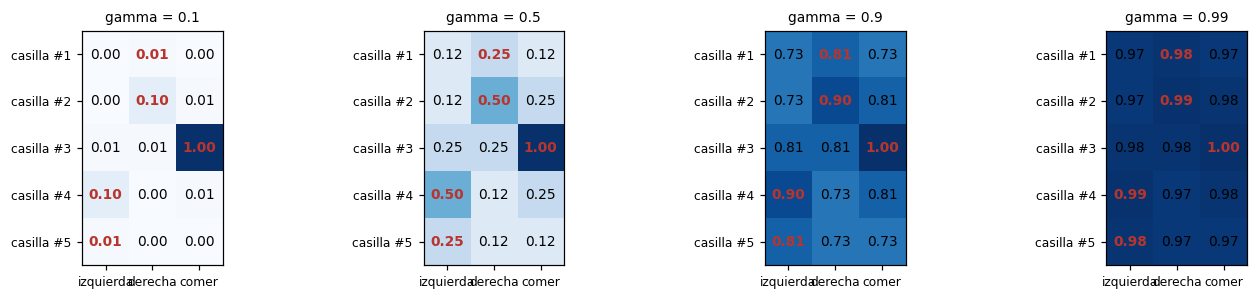

Con gamma chico el agente solo ve la casilla de al lado.
Con gamma grande el valor de la comida se propaga por toda la fila.


In [4]:
# ¿Que hace gamma? Mira hasta donde llega el valor de la comida.
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8))
for ax, g in zip(axes, [0.1, 0.5, 0.9, 0.99]):
    Qg = tabla_exacta(gamma=g)
    # Normalizamos para poder comparar la FORMA, no la escala.
    mostrar_tabla(Qg / Qg.max(), f"gamma = {g}", ax=ax, vmax=1.0)
plt.tight_layout(); plt.show()
# El valor de la comida SIEMPRE llega a todas las casillas. Lo que cambia es
# cuanto pesa al alejarse: a k casillas vale exactamente gamma^k del pico.
for g in (0.1, 0.5, 0.9, 0.99):
    Qg = tabla_exacta(gamma=g)
    proporcion = Qg[0].max() / Qg[CASILLA_COMIDA].max()
    print(f"gamma={g:<5} a dos casillas queda el {100*proporcion:6.2f}% del pico"
          f"   (gamma^2 = {g**2:.4f})")
print("\nNunca llega a cero: se encoge, no se corta.")

---
## 3. Q-learning: llenar la tabla sin conocer el mundo

Arriba hicimos trampa: usamos `transicion`, o sea el mapa completo del
mundo. Un agente de verdad **no lo tiene**. Solo puede probar, ver qué pasa,
y corregir.

Q-learning corrige un poquito cada vez que prueba algo:

$$ Q(s,a) \leftarrow Q(s,a) + \alpha\Big[\underbrace{r + \gamma \max_{a'}Q(s',a')}_{\text{lo que deberia valer}} - \underbrace{Q(s,a)}_{\text{lo que creia}}\Big] $$

Es el mismo gradient descent del notebook 0: mide el error y da un
paso pequeño en su contra. $\alpha$ es el *learning rate*.

### TODO 2

Escribe la actualización. Son dos líneas.

In [5]:
# === TODO 2 =========================================================
def actualizar(Q, s, a, r, s2, alpha=0.5, gamma=0.1):
    # objetivo = premio de ahora + gamma * el mejor valor del estado siguiente
    objetivo = 0.0                     # <-- TODO: cambia esto
    Q[s, a] = Q[s, a]                  # <-- TODO: y esto
    return Q
# ====================================================================

def q_learning(actualizar_fn, episodios=300, pasos=20, gamma=0.1,
               alpha=0.5, semilla=0, guardar_cada=5):
    rng = np.random.default_rng(semilla)
    Q = np.zeros((N_ESTADOS, N_ACCIONES))
    fotos, error = [], []
    for ep in range(episodios):
        s = int(rng.integers(N_ESTADOS))
        epsilon = max(0.1, 1.0 - ep / (0.7 * episodios))
        for _ in range(pasos):
            a = int(rng.integers(N_ACCIONES)) if rng.random() < epsilon else int(Q[s].argmax())
            s2, r = transicion(s, a)
            Q = actualizar_fn(Q, s, a, r, s2, alpha, gamma)
            s = s2
        error.append(np.abs(Q - Q_exacta).max())
        if ep % guardar_cada == 0:
            fotos.append(Q.copy())
    return Q, fotos, error

Q_roto, _, _ = q_learning(actualizar)
print("Con la funcion sin terminar, la tabla se queda asi:")
print(np.round(Q_roto, 4))

Con la funcion sin terminar, la tabla se queda asi:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


### Solución

Ejecuta esta celda **después** de intentarlo.

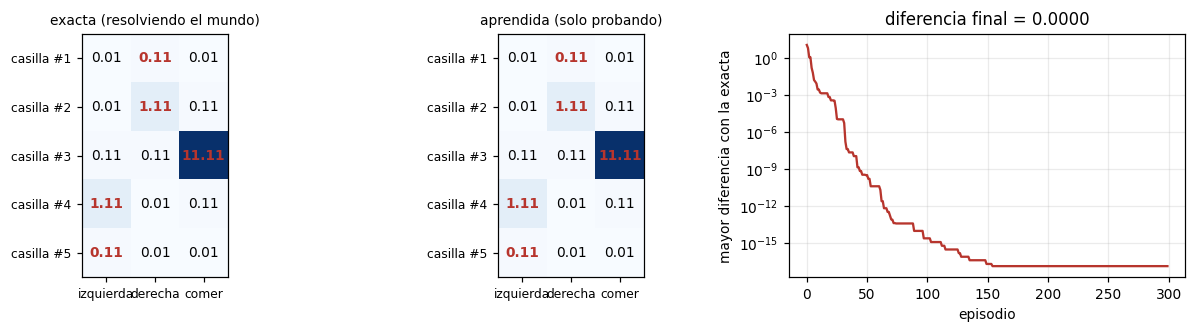

Misma tabla. Una la calculamos sabiendo el mundo, la otra la descubrio
el agente a base de probar, sin que nadie le explicara nada.


In [6]:
def actualizar(Q, s, a, r, s2, alpha=0.5, gamma=0.1):
    objetivo = r + gamma * Q[s2].max()
    Q[s, a] = Q[s, a] + alpha * (objetivo - Q[s, a])
    return Q

Q_aprendida, fotos, error = q_learning(actualizar, episodios=300)

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(11.5, 3.1))
mostrar_tabla(Q_exacta,    "exacta (resolviendo el mundo)", ax=a1, vmax=Q_exacta.max())
mostrar_tabla(Q_aprendida, "aprendida (solo probando)",     ax=a2, vmax=Q_exacta.max())
a3.plot(error, color=ROJO); a3.set_yscale("log")
a3.set_xlabel("episodio"); a3.set_ylabel("mayor diferencia con la exacta")
a3.grid(alpha=.25); a3.set_title(f"diferencia final = {error[-1]:.4f}")
plt.tight_layout(); plt.show()
print("Misma tabla. Una la calculamos sabiendo el mundo, la otra la descubrio")
print("el agente a base de probar, sin que nadie le explicara nada.")

In [7]:
# La tabla llenandose, episodio a episodio.
fig, ax = plt.subplots(figsize=(4.2, 3.2), dpi=80)
im = ax.imshow(np.zeros((N_ESTADOS, N_ACCIONES)), cmap="Blues",
               vmin=0, vmax=Q_exacta.max())
textos = [[ax.text(a, s, "", ha="center", va="center", fontsize=9)
           for a in range(N_ACCIONES)] for s in range(N_ESTADOS)]
ax.set_xticks(range(N_ACCIONES)); ax.set_xticklabels(ACCIONES, fontsize=8)
ax.set_yticks(range(N_ESTADOS))
ax.set_yticklabels([f"#{i+1}" for i in range(N_ESTADOS)], fontsize=8)
tit = ax.set_title("")

def animar(k):
    Q = fotos[k]
    im.set_data(Q)
    for s in range(N_ESTADOS):
        for a in range(N_ACCIONES):
            textos[s][a].set_text(f"{Q[s,a]:.2f}")
    tit.set_text(f"episodio {k*5}")
    return [im, tit] + [t for fila in textos for t in fila]

ani = matplotlib.animation.FuncAnimation(fig, animar, frames=len(fotos), interval=90)
plt.close(fig)
ani

---
## 4. La tabla no escala

La Q-table funciona porque tiene 15 casillas. ¿Cuántas necesitaría en un
problema de verdad? Una fila por **cada estado posible**.

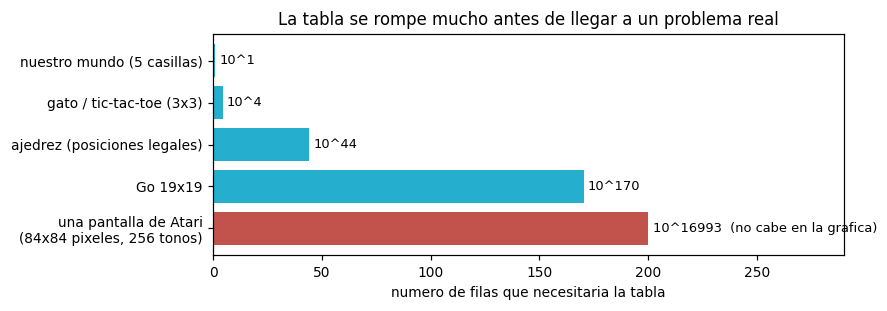

Atomos en el universo observable: unos 10^80.
Filas de la tabla para una pantalla de Atari: 10^16993.


In [8]:
# Trabajamos con el EXPONENTE en base 10: los numeros de abajo ni siquiera
# caben en un float, asi que 256 ** (84*84) daria un error de desbordamiento.
casos = [
    ("nuestro mundo (5 casillas)",                       np.log10(5)),
    ("gato / tic-tac-toe (3x3)",                         9 * np.log10(3)),
    ("ajedrez (posiciones legales)",                     44.0),
    ("Go 19x19",                                         np.log10(2.1) + 170),
    ("una pantalla de Atari\n(84x84 pixeles, 256 tonos)", 84 * 84 * np.log10(256)),
]
etiquetas  = [c[0] for c in casos]
exponentes = [c[1] for c in casos]

fig, ax = plt.subplots(figsize=(8, 2.9))
tope = 200
colores = [PETROL] * 4 + [ROJO]
ax.barh(etiquetas, [min(e, tope) for e in exponentes], color=colores, alpha=.85)
for i, e in enumerate(exponentes):
    texto = f"10^{e:.0f}" if e < tope else f"10^{e:.0f}  (no cabe en la grafica)"
    ax.text(min(e, tope) + 2, i, texto, va="center", fontsize=8.5)
ax.set_xlim(0, tope + 90); ax.set_xlabel("numero de filas que necesitaria la tabla")
ax.set_title("La tabla se rompe mucho antes de llegar a un problema real")
ax.invert_yaxis(); plt.tight_layout(); plt.show()
print(f"Atomos en el universo observable: unos 10^80.")
print(f"Filas de la tabla para una pantalla de Atari: 10^{exponentes[-1]:.0f}.")

Y hay un problema peor que el tamaño: aunque la tabla cupiera, el agente
**nunca visitaría** la mayoría de las filas. Cada fila se aprende por
separado, así que lo que aprende en una casilla no le sirve para la de al
lado.

Lo que hace falta es algo que **rellene entre los estados que sí vio**.
Eso es exactamente lo que hace una red neuronal (notebook 1).

---
## 5. Mundo continuo: la tabla se rompe de verdad

Mismo juego, pero ahora la posición es un número real entre 0 y 10, y la
comida está justo en el medio, en 5.0. Ya no hay casillas: hay
infinitos estados, y el mundo es simétrico igual que el de cinco casillas.

También subimos $\gamma$ a 0.9.

> ### Un error de verdad, y lo dejamos a la vista
>
> La primera versión de este notebook la escribió un modelo de lenguaje, y en
> este punto decía:
>
> > *"Con 0.1 el agente solo veía un paso por delante, y aquí la comida puede
> > estar a quince pasos."*
>
> Las dos mitades están mal.
>
> **1. El concepto.** $\gamma$ no es un horizonte que recorte pasos. La suma de
> Bellman incluye **siempre** toda la cadena futura y la pondera, cada paso por
> $\gamma^k$. Míralo en la tabla de arriba: con $\gamma = 0.1$ la casilla #1
> vale $0.11$, no $0$. Está a dos casillas de la comida, y $0.11 / 11.11 =
> \gamma^2$ exacto.
>
> **2. El número.** Desde un extremo hay $4.5$ unidades hasta la zona de comida
> y cada paso avanza $0.6$: son **ocho** pasos, no quince.
>
> Lo dejamos escrito a propósito. Un modelo de lenguaje redacta con total
> seguridad y a veces falla en el **concepto**, no solo en el número. Es
> justo lo que vamos a medir en el notebook 4.

Entonces, ¿por qué subir $\gamma$? No para "ver más lejos", sino para que el
premio lejano **pese** lo suficiente. A ocho pasos, con $\gamma = 0.1$ el premio
vale $0.1^8 = 10^{-8}$ veces el inmediato: no es cero, pero se pierde entre el
ruido del aprendizaje. Con $\gamma = 0.9$ vale $0.9^8 \approx 0.43$, y eso sí
guía al agente.

In [9]:
LARGO, COMIDA, TOLERANCIA, PASO = 10.0, 5.0, 0.5, 0.6

def transicion_continua(x, a):
    if a == 0:
        return max(0.0, x - PASO), 0.0
    if a == 1:
        return min(LARGO, x + PASO), 0.0
    return x, (10.0 if abs(x - COMIDA) < TOLERANCIA else 0.0)

def q_learning_cajas(n_cajas, episodios=300, pasos=50, gamma=0.9,
                     alpha=0.2, semilla=0):
    """Trocea la linea en n_cajas y usa una Q-table normal."""
    rng = np.random.default_rng(semilla)
    Q = np.zeros((n_cajas, N_ACCIONES))
    caja = lambda x: min(n_cajas - 1, int(x / LARGO * n_cajas))
    historia = []
    for ep in range(episodios):
        x = float(rng.uniform(0, LARGO)); total = 0.0
        epsilon = max(0.05, 1.0 - ep / (0.7 * episodios))
        for _ in range(pasos):
            s = caja(x)
            a = int(rng.integers(N_ACCIONES)) if rng.random() < epsilon else int(Q[s].argmax())
            x2, r = transicion_continua(x, a)
            total += r
            Q[s, a] += alpha * (r + gamma * Q[caja(x2)].max() - Q[s, a])
            x = x2
        historia.append(total)
    visitadas = int((np.abs(Q).sum(1) > 0).sum())
    return Q, historia, visitadas

CAJAS = [20, 50, 100, 400, 2000]
resultados = {}
for n in CAJAS:
    _, h, vis = q_learning_cajas(n)
    resultados[n] = (float(np.mean(h[-20:])), vis)
    print(f"{n:5d} cajas -> recompensa {resultados[n][0]:6.1f}   "
          f"estados visitados {vis:4d}/{n}")

   20 cajas -> recompensa  436.0   estados visitados   20/20
   50 cajas -> recompensa  426.5   estados visitados   50/50
  100 cajas -> recompensa  407.5   estados visitados   99/100
  400 cajas -> recompensa  397.5   estados visitados  228/400
 2000 cajas -> recompensa   79.0   estados visitados  137/2000


Cuantas más cajas, más fina es la descripción del mundo... y peor aprende.
La razón está en la última columna: con 2000 cajas el agente visita menos
del 10% de ellas. El resto de las filas siguen en cero, y una fila en cero
no dice nada.

Ahora la red neuronal, con **el mismo presupuesto** de episodios.

In [10]:
import torch
import torch.nn as nn

def deep_q_learning(episodios=300, pasos=50, gamma=0.9, lr=3e-3,
                    lote=64, semilla=0):
    torch.manual_seed(semilla)
    rng = np.random.default_rng(semilla)
    # La red REEMPLAZA a la tabla: entra la posicion, salen los 3 valores Q.
    # tanh, la misma activacion del notebook 1: la funcion que aprende sale
    # suave en vez de quebrada, y la recompensa es la misma.
    red = nn.Sequential(nn.Linear(1, 32), nn.Tanh(),
                        nn.Linear(32, 32), nn.Tanh(),
                        nn.Linear(32, N_ACCIONES))
    opt = torch.optim.Adam(red.parameters(), lr=lr)
    memoria, historia = [], []
    for ep in range(episodios):
        x = float(rng.uniform(0, LARGO)); total = 0.0
        epsilon = max(0.05, 1.0 - ep / (0.7 * episodios))
        for t in range(pasos):
            if rng.random() < epsilon:
                a = int(rng.integers(N_ACCIONES))
            else:
                with torch.no_grad():
                    a = int(red(torch.tensor([[x / LARGO]])).argmax())
            x2, r = transicion_continua(x, a)
            total += r
            memoria.append((x / LARGO, a, r, x2 / LARGO))     # experience replay
            x = x2
            if len(memoria) >= lote and t % 2 == 0:
                idx = rng.integers(0, len(memoria), lote)
                S  = torch.tensor([[memoria[i][0]] for i in idx], dtype=torch.float32)
                A  = torch.tensor([memoria[i][1] for i in idx])
                R  = torch.tensor([memoria[i][2] for i in idx], dtype=torch.float32)
                S2 = torch.tensor([[memoria[i][3]] for i in idx], dtype=torch.float32)
                with torch.no_grad():
                    objetivo = R + gamma * red(S2).max(1).values   # Bellman, otra vez
                prediccion = red(S).gather(1, A.unsqueeze(1)).squeeze(1)
                perdida = ((prediccion - objetivo) ** 2).mean()
                opt.zero_grad(); perdida.backward(); opt.step()
        historia.append(total)
    return red, historia

import time
t0 = time.time()
red, historia_red = deep_q_learning(episodios=300)
print(f"Entrenado en {time.time()-t0:.1f} s")
print(f"Recompensa de los ultimos 20 episodios: {np.mean(historia_red[-20:]):.1f}")

Entrenado en 17.8 s
Recompensa de los ultimos 20 episodios: 435.0


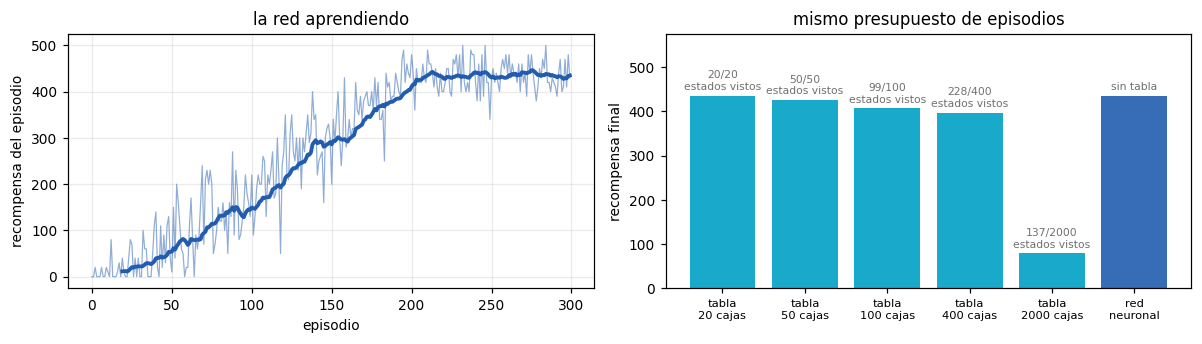

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))

a1.plot(historia_red, color=AZUL, lw=.8, alpha=.5)
suave = np.convolve(historia_red, np.ones(20) / 20, mode="valid")
a1.plot(range(19, 19 + len(suave)), suave, color=AZUL, lw=2.5)
a1.set_xlabel("episodio"); a1.set_ylabel("recompensa del episodio")
a1.grid(alpha=.25); a1.set_title("la red aprendiendo")

nombres = [f"tabla\n{n} cajas" for n in CAJAS] + ["red\nneuronal"]
valores = [resultados[n][0] for n in CAJAS] + [float(np.mean(historia_red[-20:]))]
colores = [PETROL] * len(CAJAS) + [AZUL]
barras = a2.bar(nombres, valores, color=colores, alpha=.9)
a2.set_ylim(0, max(valores) * 1.32)          # aire para las etiquetas
for b, n in zip(barras[:-1], CAJAS):
    a2.text(b.get_x() + b.get_width() / 2, b.get_height() + max(valores) * .03,
            f"{resultados[n][1]}/{n}\nestados vistos", ha="center", fontsize=7,
            color=GRIS)
a2.text(barras[-1].get_x() + barras[-1].get_width() / 2,
        barras[-1].get_height() + max(valores) * .03,
        "sin tabla", ha="center", fontsize=7, color=GRIS)
a2.set_ylabel("recompensa final"); a2.set_title("mismo presupuesto de episodios")
a2.tick_params(axis="x", labelsize=7.5)
plt.tight_layout(); plt.show()

### Por qué gana la red

La tabla aprende cada estado por separado. La red aprende **una función**
de la posición, así que lo que descubre en un punto lo aprovecha en todos
los de al lado. Es el interpolador del notebook 1, aplicado a los valores Q.

Mira la función que aprendió: es suave, y no tiene 2000 huecos.

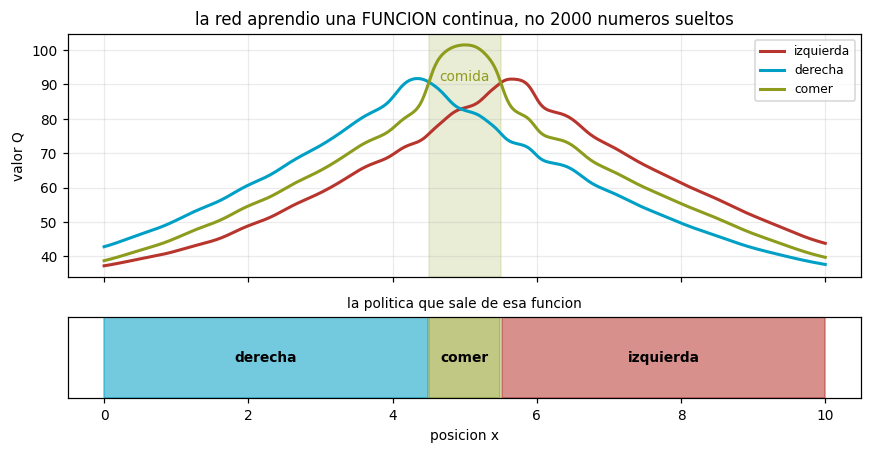

Izquierda si te pasaste, derecha si te falta, comer donde esta la comida.
Nadie se lo dijo: lo dedujo de recibir +10 de vez en cuando.


In [12]:
xs = np.linspace(0, LARGO, 400)
with torch.no_grad():
    Qs = red(torch.tensor(xs.reshape(-1, 1) / LARGO, dtype=torch.float32)).numpy()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 4.2),
                             gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
for a, (nombre, color) in enumerate(zip(ACCIONES, [ROJO, PETROL, VERDE])):
    a1.plot(xs, Qs[:, a], color=color, lw=2, label=nombre)
a1.axvspan(COMIDA - TOLERANCIA, COMIDA + TOLERANCIA, color=VERDE, alpha=.18)
a1.text(COMIDA, a1.get_ylim()[1] * .90, "comida", ha="center", va="top",
        color=VERDE, fontsize=9)
a1.set_ylabel("valor Q"); a1.legend(fontsize=8); a1.grid(alpha=.25)
a1.set_title("la red aprendio una FUNCION continua, no 2000 numeros sueltos")

politica = Qs.argmax(1)
for a, color in enumerate([ROJO, PETROL, VERDE]):
    zona = politica == a
    a2.fill_between(xs, 0, 1, where=zona, color=color, alpha=.55, step="mid")
    if zona.any():                       # el nombre de la accion, dentro de su zona
        a2.text(xs[zona].mean(), .5, ACCIONES[a], ha="center", va="center",
                fontsize=9, color="black", fontweight="bold")
a2.set_ylim(0, 1); a2.set_yticks([]); a2.set_xlabel("posicion x")
a2.set_title("la politica que sale de esa funcion", fontsize=9)
plt.tight_layout(); plt.show()
print("Izquierda si te pasaste, derecha si te falta, comer donde esta la comida.")
print("Nadie se lo dijo: lo dedujo de recibir +10 de vez en cuando.")

---
## Resumen

1. Una **Q-table** guarda cuánto vale cada acción en cada estado.
2. La **ecuación de Bellman** relaciona el valor de ahora con el de después.
3. **Q-learning** llena esa tabla probando, sin conocer el mundo.
4. La tabla se rompe en cuanto hay muchos estados: no cabe, y sobre todo
   el agente nunca visita la mayoría.
5. **Deep Q-learning** cambia la tabla por una red. La red interpola, así
   que aprovecha lo aprendido en un estado para los parecidos.

Es el mismo salto que dio DeepMind en 2015 para jugar Atari, y el mismo
que hay detrás de AlphaGo.

En el siguiente notebook cambiamos de tema solo en apariencia: veremos que
un modelo de lenguaje empieza siendo **otra tabla**, y se rompe por la misma
razón.